In [3]:
from pathlib import Path
import pandas as pd
import numpy as np

print(Path.cwd())
import matplotlib.pyplot as plt
import seaborn as sns

c:\Users\DELL\Documents\Github\trialscope-clinical-trial-representation\notebooks


In [4]:
csv_files = list(Path("../data/raw").glob("*.csv"))

print(csv_files)

[WindowsPath('../data/raw/clinical_trials_type_2_diabetes_raw.csv')]


In [5]:
raw_file = csv_files[0]
trials = pd.read_csv(raw_file)
trials.head()

,NCT Number,Study Title,Study URL,Acronym,Study Status,Brief Summary,Study Results,Conditions,Interventions,Primary Outcome Measures,...,Study Design,Other IDs,Start Date,Primary Completion Date,Completion Date,First Posted,Results First Posted,Last Update Posted,Locations,Study Documents
0,NCT07290231,Effects of Core Strengthening Exercises With D...,https://clinicaltrials.gov/study/NCT07290231,NaN,RECRUITING,Diabetes type II is a metabolic syndrome invol...,NO,Diabetes Type II,OTHER: Core Strengthening with Diaphragmatic B...,"pulmonary Function, Pulmonary function will be...",...,Allocation: RANDOMIZED | Intervention Model: P...,FUI/CTR/2025/93,2025-08-06,2026-01-03,2026-02-10,2025-12-18,NaN,2025-12-18,Foundation University College of Physical Ther...,NaN
1,NCT02074540,The Influence of Health Beliefs and Uncertaint...,https://clinicaltrials.gov/study/NCT02074540,NaN,UNKNOWN,To determine the predicting factors and indica...,NO,Diabetes Type II,OTHER: Questionnaire,"Insulin adherence, Average number of positive ...",...,Observational Model: CASE_ONLY | Time Perspect...,HYMC-0005-14,2014-04,2014-08,2014-12,2014-02-28,NaN,2014-02-28,NaN,NaN
2,NCT02326129,Novel Biomarker for Development of T2D,https://clinicaltrials.gov/study/NCT02326129,NaN,COMPLETED,The investigators wants to determine if 11β-HS...,NO,Diabetes Type II,NaN,Relationship between 11β-HSD1 and 5α-reductase...,...,Observational Model: CASE_CONTROL | Time Persp...,Pro00057460|K23DK117067,2015-02,2023-04-05,2023-04-05,2014-12-25,NaN,2023-08-07,"Pennington Biomedical Research center, Baton R...",NaN
3,NCT06864546,A Participatory Approach to Support Glucose To...,https://clinicaltrials.gov/study/NCT06864546,GluToTrack,RECRUITING,Recent studies show that lifestyle interventio...,NO,"Type 2 Diabetes Mellitus, Non Insulin Dependent",BEHAVIORAL: Physical activity intervention,Change in Blood Glucose Control Over the Two S...,...,Allocation: NA | Intervention Model: SINGLE_GR...,CTSPV46-24|P2022XSFA7|F53D23008460001|C53D2300...,2025-05,2025-12,2026-01-15,2025-03-07,NaN,2025-04-30,"Istituti Clinici Scientifici Maugeri di Pavia,...",NaN
4,NCT04501341,BM-MNC and UCMSC for Type 2 Diabetes Mellitus ...,https://clinicaltrials.gov/study/NCT04501341,NaN,UNKNOWN,The aim of this preliminary study is to evalua...,NO,T2D,"BIOLOGICAL: Bone-marrow aspiration, Intra-panc...",Decreasing total daily dose of insulin (>= 30%...,...,Allocation: NON_RANDOMIZED | Intervention Mode...,132/PT02.FK25/U.Eu113/METEND/V,2016-03-14,2021-12-01,2021-12-01,2020-08-06,NaN,2020-08-06,"Faculty of Medicine, Universitas Indonesia, Ja...",NaN


In [6]:
print("Files inside data/raw:")
print(list(Path("../data/raw").iterdir()))

print("\nAll CSV files found anywhere in this project:")
print(list(Path("..").rglob("*.csv")))

Files inside data/raw:
[WindowsPath('../data/raw/.gitkeep'), WindowsPath('../data/raw/clinical_trials_type_2_diabetes_raw.csv')]

All CSV files found anywhere in this project:
[WindowsPath('../data/processed/trialscope_clean.csv'), WindowsPath('../data/processed/trialscope_locations_long.csv'), WindowsPath('../data/raw/clinical_trials_type_2_diabetes_raw.csv'), WindowsPath('../.venv/Lib/site-packages/tornado/test/csv_translations/fr_FR.csv'), WindowsPath('../.venv/Lib/site-packages/numpy/_core/tests/data/umath-validation-set-arccos.csv'), WindowsPath('../.venv/Lib/site-packages/numpy/_core/tests/data/umath-validation-set-arccosh.csv'), WindowsPath('../.venv/Lib/site-packages/numpy/_core/tests/data/umath-validation-set-arcsin.csv'), WindowsPath('../.venv/Lib/site-packages/numpy/_core/tests/data/umath-validation-set-arcsinh.csv'), WindowsPath('../.venv/Lib/site-packages/numpy/_core/tests/data/umath-validation-set-arctan.csv'), WindowsPath('../.venv/Lib/site-packages/numpy/_core/tests/dat

In [7]:
number_of_trials = trials.shape[0]
number_of_columns = trials.shape[1]

print(f"Number of trials: {number_of_trials:,}")
print(f"Number of columns: {number_of_columns}")

Number of trials: 1,000
Number of columns: 30


In [8]:
for column in trials.columns:
    print("-", column)

- NCT Number
- Study Title
- Study URL
- Acronym
- Study Status
- Brief Summary
- Study Results
- Conditions
- Interventions
- Primary Outcome Measures
- Secondary Outcome Measures
- Other Outcome Measures
- Sponsor
- Collaborators
- Sex
- Age
- Phases
- Enrollment
- Funder Type
- Study Type
- Study Design
- Other IDs
- Start Date
- Primary Completion Date
- Completion Date
- First Posted
- Results First Posted
- Last Update Posted
- Locations
- Study Documents


In [9]:
analysis_columns = [
    "NCT Number",
    "Study Title",
    "Study Status",
    "Conditions",
    "Sponsor",
    "Sex",
    "Age",
    "Phases",
    "Enrollment",
    "Funder Type",
    "Study Type",
    "Start Date",
    "Completion Date",
    "Locations"
]

trial_audit = trials[analysis_columns].copy()

trial_audit.head()

,NCT Number,Study Title,Study Status,Conditions,Sponsor,Sex,Age,Phases,Enrollment,Funder Type,Study Type,Start Date,Completion Date,Locations
0,NCT07290231,Effects of Core Strengthening Exercises With D...,RECRUITING,Diabetes Type II,Foundation University Islamabad,ALL,ADULT,NaN,56.0,OTHER,INTERVENTIONAL,2025-08-06,2026-02-10,Foundation University College of Physical Ther...
1,NCT02074540,The Influence of Health Beliefs and Uncertaint...,UNKNOWN,Diabetes Type II,Hillel Yaffe Medical Center,ALL,"ADULT, OLDER_ADULT",NaN,100.0,OTHER_GOV,OBSERVATIONAL,2014-04,2014-12,NaN
2,NCT02326129,Novel Biomarker for Development of T2D,COMPLETED,Diabetes Type II,Duke University,ALL,"CHILD, ADULT",NaN,202.0,OTHER,OBSERVATIONAL,2015-02,2023-04-05,"Pennington Biomedical Research center, Baton R..."
3,NCT06864546,A Participatory Approach to Support Glucose To...,RECRUITING,"Type 2 Diabetes Mellitus, Non Insulin Dependent",Enea Parimbelli,ALL,"ADULT, OLDER_ADULT",NaN,20.0,OTHER,INTERVENTIONAL,2025-05,2026-01-15,"Istituti Clinici Scientifici Maugeri di Pavia,..."
4,NCT04501341,BM-MNC and UCMSC for Type 2 Diabetes Mellitus ...,UNKNOWN,T2D,Indonesia University,ALL,"ADULT, OLDER_ADULT",PHASE1|PHASE2,15.0,OTHER,INTERVENTIONAL,2016-03-14,2021-12-01,"Faculty of Medicine, Universitas Indonesia, Ja..."


In [10]:
data_quality_audit = pd.DataFrame({
    "data_type": trial_audit.dtypes.astype(str),
    "missing_values": trial_audit.isna().sum(),
    "missing_percentage": (trial_audit.isna().mean() * 100).round(1)
})

data_quality_audit.sort_values(
    by="missing_percentage",
    ascending=False
)

,data_type,missing_values,missing_percentage
Phases,str,511,51.1
Locations,str,103,10.3
Completion Date,str,29,2.9
Enrollment,float64,10,1.0
Start Date,str,4,0.4
NCT Number,str,0,0.0
Sex,str,0,0.0
Sponsor,str,0,0.0
Conditions,str,0,0.0
Study Status,str,0,0.0


In [11]:
phase_by_study_type = (
    trial_audit
    .assign(has_phase=trial_audit["Phases"].notna())
    .groupby("Study Type")
    .agg(
        total_studies=("NCT Number", "size"),
        studies_with_phase=("has_phase", "sum")
    )
)

phase_by_study_type["phase_missing"] = (
    phase_by_study_type["total_studies"]
    - phase_by_study_type["studies_with_phase"]
)

phase_by_study_type["phase_missing_percentage"] = (
    phase_by_study_type["phase_missing"]
    / phase_by_study_type["total_studies"]
    * 100
).round(1)

phase_by_study_type

,total_studies,studies_with_phase,phase_missing,phase_missing_percentage
Study Type,,,,
EXPANDED_ACCESS,1,0,1,100.0
INTERVENTIONAL,877,489,388,44.2
OBSERVATIONAL,122,0,122,100.0


## Initial data-quality finding: missing clinical-trial phases

Phase information is missing for 51.1% of all records. This is expected for all
observational studies in this dataset, as observational studies do not typically
use clinical trial phases.

Among interventional studies, 44.2% also have no phase recorded. These values
will be retained as missing rather than filled in, because phase may not apply
to every type of intervention.

In [12]:
print("Sex eligibility:")
print(trial_audit["Sex"].value_counts())

print("\nAge eligibility:")
print(trial_audit["Age"].value_counts())

Sex eligibility:
Sex
ALL       967
MALE       26
FEMALE      7
Name: count, dtype: int64

Age eligibility:
Age
ADULT, OLDER_ADULT           842
ADULT                         95
CHILD, ADULT, OLDER_ADULT     30
CHILD, ADULT                  18
CHILD                          8
OLDER_ADULT                    7
Name: count, dtype: int64


In [13]:
trial_audit["includes_older_adults"] = trial_audit["Age"].str.contains(
    "OLDER_ADULT",
    na=False
)

trial_audit["includes_children"] = trial_audit["Age"].str.contains(
    "CHILD",
    na=False
)

representation_summary = pd.DataFrame({
    "metric": [
        "Open to all sexes",
        "Male-only trials",
        "Female-only trials",
        "Includes older adults",
        "Includes children"
    ],
    "trial_count": [
        (trial_audit["Sex"] == "ALL").sum(),
        (trial_audit["Sex"] == "MALE").sum(),
        (trial_audit["Sex"] == "FEMALE").sum(),
        trial_audit["includes_older_adults"].sum(),
        trial_audit["includes_children"].sum()
    ]
})

representation_summary["percentage"] = (
    representation_summary["trial_count"]
    / len(trial_audit)
    * 100
).round(1)

representation_summary

,metric,trial_count,percentage
0,Open to all sexes,967,96.7
1,Male-only trials,26,2.6
2,Female-only trials,7,0.7
3,Includes older adults,879,87.9
4,Includes children,56,5.6


## Initial representation profile

Among the 1,000 downloaded Type 2 diabetes study records, 96.7% are open to
all sexes. Most studies (87.9%) include older adults in their eligibility
criteria, while only 5.6% include children.

These figures describe stated eligibility criteria, not the demographics of
participants who actually enrolled.


In [14]:
trial_audit["Enrollment"].describe()

count       990.000000
mean        769.854545
std        7821.813476
min           0.000000
25%          40.000000
50%          90.000000
75%         228.750000
max      200000.000000
Name: Enrollment, dtype: float64

In [15]:
largest_trials = (
    trial_audit[
        [
            "NCT Number",
            "Study Title",
            "Enrollment",
            "Study Type",
            "Study Status",
            "Sex",
            "Age"
        ]
    ]
    .sort_values("Enrollment", ascending=False)
    .head(10)
)

largest_trials

,NCT Number,Study Title,Enrollment,Study Type,Study Status,Sex,Age
969,NCT02636192,Study on Incidence of Diabetic Ketoacidosis Am...,200000.0,OBSERVATIONAL,COMPLETED,ALL,"ADULT, OLDER_ADULT"
971,NCT06251323,"Implementing Scalable, PAtient-centered, Team-...",119680.0,INTERVENTIONAL,RECRUITING,ALL,"ADULT, OLDER_ADULT"
7,NCT01121315,A Retrospective Study of Cardiovascular Events...,58326.0,OBSERVATIONAL,COMPLETED,ALL,"CHILD, ADULT, OLDER_ADULT"
909,NCT06351748,Real-world Study of CHina Ozempic cLinicAl pRa...,34238.0,OBSERVATIONAL,COMPLETED,ALL,"ADULT, OLDER_ADULT"
622,NCT03249506,Cardiovascular Outcomes in Participants With T...,25358.0,OBSERVATIONAL,COMPLETED,ALL,"ADULT, OLDER_ADULT"
90,NCT03025919,Evaluation of Innovated Screening Tools for Ty...,20000.0,OBSERVATIONAL,UNKNOWN,ALL,"CHILD, ADULT, OLDER_ADULT"
460,NCT05926414,To Evaluate the Efficacy and Safety of Envlo T...,15000.0,OBSERVATIONAL,ACTIVE_NOT_RECRUITING,ALL,"ADULT, OLDER_ADULT"
278,NCT06561126,Engagement of coMmunity Through Participatory ...,12744.0,INTERVENTIONAL,RECRUITING,ALL,"ADULT, OLDER_ADULT"
876,NCT00069784,The ORIGIN Trial (Outcome Reduction With Initi...,12537.0,INTERVENTIONAL,COMPLETED,ALL,"ADULT, OLDER_ADULT"
545,NCT06647888,Evaluation of Enavogliflozin's Efficacy and Sa...,12000.0,OBSERVATIONAL,RECRUITING,ALL,"ADULT, OLDER_ADULT"


In [16]:
duplicate_nct_numbers = trial_audit["NCT Number"].duplicated().sum()

zero_enrollment = (trial_audit["Enrollment"] == 0).sum()

missing_enrollment = trial_audit["Enrollment"].isna().sum()

print(f"Duplicate NCT numbers: {duplicate_nct_numbers}")
print(f"Studies with zero enrollment: {zero_enrollment}")
print(f"Studies with missing enrollment: {missing_enrollment}")

Duplicate NCT numbers: 0
Studies with zero enrollment: 18
Studies with missing enrollment: 10


In [17]:
trial_clean = trial_audit.copy()

trial_clean["start_year"] = pd.to_numeric(
    trial_clean["Start Date"].str.extract(r"(\d{4})")[0],
    errors="coerce"
)

trial_clean["completion_year"] = pd.to_numeric(
    trial_clean["Completion Date"].str.extract(r"(\d{4})")[0],
    errors="coerce"
)

trial_clean["has_reported_enrollment"] = trial_clean["Enrollment"].notna()

trial_clean["has_zero_enrollment"] = trial_clean["Enrollment"].eq(0)

trial_clean[
    [
        "NCT Number",
        "Study Status",
        "Enrollment",
        "start_year",
        "completion_year",
        "has_reported_enrollment",
        "has_zero_enrollment"
    ]
].head()

,NCT Number,Study Status,Enrollment,start_year,completion_year,has_reported_enrollment,has_zero_enrollment
0,NCT07290231,RECRUITING,56.0,2025.0,2026.0,True,False
1,NCT02074540,UNKNOWN,100.0,2014.0,2014.0,True,False
2,NCT02326129,COMPLETED,202.0,2015.0,2023.0,True,False
3,NCT06864546,RECRUITING,20.0,2025.0,2026.0,True,False
4,NCT04501341,UNKNOWN,15.0,2016.0,2021.0,True,False


In [18]:
processed_file = Path("../data/processed/trialscope_clean.csv")

trial_clean.to_csv(processed_file, index=False)

print(f"Saved processed data to: {processed_file}")
print(f"File exists: {processed_file.exists()}")

Saved processed data to: ..\data\processed\trialscope_clean.csv
File exists: True


In [19]:
import duckdb

connection = duckdb.connect()

connection.register("trial_clean_data", trial_clean)

print("SQL table registered successfully")

SQL table registered successfully


In [20]:
status_summary_sql = connection.execute("""
    SELECT
        "Study Status" AS study_status,
        COUNT(*) AS trial_count
    FROM trial_clean_data
    GROUP BY "Study Status"
    ORDER BY trial_count DESC
""").df()

status_summary_sql

,study_status,trial_count
0,COMPLETED,571
1,UNKNOWN,146
2,RECRUITING,123
3,NOT_YET_RECRUITING,64
4,TERMINATED,35
5,ACTIVE_NOT_RECRUITING,32
6,WITHDRAWN,18
7,ENROLLING_BY_INVITATION,8
8,SUSPENDED,2
9,AVAILABLE,1


In [21]:
representation_by_study_type_sql = connection.execute("""
    SELECT
        "Study Type" AS study_type,
        COUNT(*) AS trial_count,

        SUM(
            CASE
                WHEN "Sex" = 'ALL' THEN 1
                ELSE 0
            END
        ) AS open_to_all_sexes,

        ROUND(
            100.0 * SUM(
                CASE
                    WHEN "Sex" = 'ALL' THEN 1
                    ELSE 0
                END
            ) / COUNT(*),
            1
        ) AS all_sexes_percentage,

        SUM(
            CASE
                WHEN "Age" LIKE '%OLDER_ADULT%' THEN 1
                ELSE 0
            END
        ) AS includes_older_adults

    FROM trial_clean_data

    GROUP BY "Study Type"

    ORDER BY trial_count DESC
""").df()

representation_by_study_type_sql

,study_type,trial_count,open_to_all_sexes,all_sexes_percentage,includes_older_adults
0,INTERVENTIONAL,877,848.0,96.7,766.0
1,OBSERVATIONAL,122,118.0,96.7,112.0
2,EXPANDED_ACCESS,1,1.0,100.0,1.0


## Representation by study type

Interventional and observational studies were similarly likely to be open to all
sexes: 96.7% in both groups.

Eligibility for older adults was high in both categories, although it was
slightly lower in interventional studies (87.3%) than observational studies
(91.8%). This analysis describes eligibility criteria rather than actual
participant demographics.

## Trial size by study type

Because a few very large studies can pull the average upward, I compare both
the median and mean reported enrollment. The median gives a better picture of
a typical study in this dataset.

In [22]:
enrollment_by_study_type_sql = connection.execute("""
    SELECT
        "Study Type" AS study_type,
        COUNT("Enrollment") AS studies_with_reported_enrollment,
        ROUND(MEDIAN("Enrollment"), 1) AS median_enrollment,
        ROUND(AVG("Enrollment"), 1) AS mean_enrollment,
        MAX("Enrollment") AS largest_enrollment
    FROM trial_clean_data
    WHERE "Enrollment" IS NOT NULL
    GROUP BY "Study Type"
    ORDER BY studies_with_reported_enrollment DESC
""").df()

enrollment_by_study_type_sql

,study_type,studies_with_reported_enrollment,median_enrollment,mean_enrollment,largest_enrollment
0,INTERVENTIONAL,869,80.0,344.0,119680.0
1,OBSERVATIONAL,121,250.0,3828.0,200000.0


### Finding

Among studies with reported enrollment, observational studies had a higher
typical trial size than interventional studies: median enrollment was 250
versus 80 participants.

The mean enrollment is much larger than the median in both groups, especially
for observational studies (3,828 mean versus 250 median). This shows that a
small number of very large studies skew the average upward; therefore, median
enrollment is more representative of a typical study in this dataset.

Expanded-access records are not shown because the single record had no
reported enrollment.

In [23]:
trials_by_start_year_sql = connection.execute("""
    SELECT
        start_year,
        COUNT(*) AS trial_count,
        ROUND(MEDIAN("Enrollment"), 1) AS median_enrollment,

        ROUND(
            100.0 * SUM(
                CASE
                    WHEN "Sex" = 'ALL' THEN 1
                    ELSE 0
                END
            ) / COUNT(*),
            1
        ) AS all_sexes_percentage

    FROM trial_clean_data
    WHERE start_year IS NOT NULL
    GROUP BY start_year
    ORDER BY start_year DESC
""").df()

trials_by_start_year_sql.head(10)

,start_year,trial_count,median_enrollment,all_sexes_percentage
0,2027.0,3,100.0,100.0
1,2026.0,87,108.0,96.6
2,2025.0,93,104.0,97.8
3,2024.0,99,144.0,100.0
4,2023.0,80,97.0,100.0
5,2022.0,68,81.5,95.6
6,2021.0,49,63.0,100.0
7,2020.0,43,58.0,97.7
8,2019.0,44,109.5,90.9
9,2018.0,40,46.5,92.5


### Exploratory time pattern

Across the displayed start years, between 90.9% and 100.0% of records were
open to all sexes. This suggests broadly inclusive stated sex eligibility in
this downloaded sample.

This is an exploratory comparison only. The dataset contains the top 1,000
search results rather than all registry records, and recent or future start
years can contain incomplete and planned studies.

In [24]:
funder_summary_sql = connection.execute("""
    SELECT
        "Funder Type" AS funder_type,
        COUNT(*) AS trial_count,
        ROUND(
            100.0 * COUNT(*) / SUM(COUNT(*)) OVER (),
            1
        ) AS percentage_of_records,
        ROUND(MEDIAN("Enrollment"), 1) AS median_enrollment
    FROM trial_clean_data
    GROUP BY "Funder Type"
    ORDER BY trial_count DESC
""").df()

funder_summary_sql

,funder_type,trial_count,percentage_of_records,median_enrollment
0,OTHER,534,53.4,71.0
1,INDUSTRY,438,43.8,120.0
2,OTHER_GOV,13,1.3,138.0
3,NIH,7,0.7,50.0
4,FED,5,0.5,120.0
5,NETWORK,2,0.2,110.5
6,INDIV,1,0.1,15.0


### Funding profile

More than half of the downloaded records were classified as `OTHER` funder type
(53.4%), followed by `INDUSTRY` (43.8%). Industry-funded records had a higher
median reported enrollment (120) than `OTHER` records (71).

`OTHER` is a ClinicalTrials.gov classification and should not be interpreted as
a single kind of organisation. It can include universities, hospitals,
foundations, or other non-industry sponsors.

In [25]:
top_sponsors_sql = connection.execute("""
    SELECT
        "Sponsor" AS sponsor,
        "Funder Type" AS funder_type,
        COUNT(*) AS trial_count,
        ROUND(MEDIAN("Enrollment"), 1) AS median_enrollment
    FROM trial_clean_data
    GROUP BY "Sponsor", "Funder Type"
    HAVING COUNT(*) >= 5
    ORDER BY trial_count DESC, sponsor
    LIMIT 15
""").df()

top_sponsors_sql

,sponsor,funder_type,trial_count,median_enrollment
0,Eli Lilly and Company,INDUSTRY,41,105.5
1,AstraZeneca,INDUSTRY,39,270.0
2,Chong Kun Dang Pharmaceutical,INDUSTRY,22,29.0
3,Merck Sharp & Dohme LLC,INDUSTRY,19,111.0
4,Novo Nordisk A/S,INDUSTRY,16,344.0
5,GlaxoSmithKline,INDUSTRY,15,32.0
6,Daewoong Pharmaceutical Co. LTD.,INDUSTRY,14,200.0
7,Pfizer,INDUSTRY,7,34.0
8,Sanofi,INDUSTRY,7,105.0
9,Bristol-Myers Squibb,INDUSTRY,6,208.5


### Sponsor concentration

Among sponsors appearing in at least five records, the most frequent were Eli
Lilly and Company (41 studies) and AstraZeneca (39 studies). The top-sponsor
table is dominated by industry organisations, which is consistent with the
large industry share in the funder-type analysis.

This table counts records in the downloaded sample; it does not measure market
share, study quality, or the total global clinical-trial activity of a sponsor.

In [26]:
location_examples = trial_clean[
    ["NCT Number", "Study Title", "Locations"]
].dropna().head(3)

location_examples

,NCT Number,Study Title,Locations
0,NCT07290231,Effects of Core Strengthening Exercises With D...,Foundation University College of Physical Ther...
2,NCT02326129,Novel Biomarker for Development of T2D,"Pennington Biomedical Research center, Baton R..."
3,NCT06864546,A Participatory Approach to Support Glucose To...,"Istituti Clinici Scientifici Maugeri di Pavia,..."


In [27]:
for i, location in enumerate(trial_clean["Locations"].dropna().head(3), start=1):
    print(f"\n--- Location example {i} ---")
    print(location)


--- Location example 1 ---
Foundation University College of Physical Therapy, Islamabad, 44000, Islamabad, Pakistan

--- Location example 2 ---
Pennington Biomedical Research center, Baton Rouge, Louisiana, 70803, United States|UNC Chapel Hill, Chapel Hill, North Carolina, 27514, United States|Duke University, Durham, North Carolina, 27710, United States

--- Location example 3 ---
Istituti Clinici Scientifici Maugeri di Pavia, Pavia, Pavia, 27100, Italy


In [28]:
locations_long = (
    trial_clean[["NCT Number", "Locations"]]
    .dropna()
    .assign(location_site=lambda data: data["Locations"].str.split("|"))
    .explode("location_site")
)

locations_long["country"] = (
    locations_long["location_site"]
    .str.rsplit(",", n=1)
    .str[-1]
    .str.strip()
)

locations_long.head()

,NCT Number,Locations,location_site,country
0,NCT07290231,Foundation University College of Physical Ther...,Foundation University College of Physical Ther...,Pakistan
2,NCT02326129,"Pennington Biomedical Research center, Baton R...","Pennington Biomedical Research center, Baton R...",United States
2,NCT02326129,"Pennington Biomedical Research center, Baton R...","UNC Chapel Hill, Chapel Hill, North Carolina, ...",United States
2,NCT02326129,"Pennington Biomedical Research center, Baton R...","Duke University, Durham, North Carolina, 27710...",United States
3,NCT06864546,"Istituti Clinici Scientifici Maugeri di Pavia,...","Istituti Clinici Scientifici Maugeri di Pavia,...",Italy


In [29]:
country_summary = (
    locations_long["country"]
    .value_counts()
    .rename_axis("country")
    .reset_index(name="site_count")
)

country_summary.head(15)

,country,site_count
0,United States,3362
1,China,571
2,Germany,300
3,India,298
4,Japan,284
5,South Korea,267
6,United Kingdom,225
7,Poland,223
8,Canada,215
9,Russia,176


### Geographic distribution of reported sites

The United States had the largest number of reported study sites (3,362) in
this downloaded sample. China (571), Germany (300), India (298), Japan (284),
and South Korea (267) were also among the most frequently recorded countries.

These are counts of registry-listed study sites, not participant counts or a
measure of national research quality. A single multi-country trial can
contribute sites to several countries. In addition, this project uses the top
1,000 search results rather than the full ClinicalTrials.gov registry.

In [30]:
locations_file = Path("../data/processed/trialscope_locations_long.csv")

locations_long[
    ["NCT Number", "location_site", "country"]
].to_csv(locations_file, index=False)

print(f"Saved location table to: {locations_file}")
print(f"Number of reported sites: {len(locations_long):,}")
print(f"Number of countries: {locations_long['country'].nunique():,}")

Saved location table to: ..\data\processed\trialscope_locations_long.csv
Number of reported sites: 7,968
Number of countries: 84


In [31]:
countries_per_trial = (
    locations_long
    .groupby("NCT Number")["country"]
    .nunique()
    .rename("country_count")
)

location_scope = (
    trial_clean[["NCT Number", "Locations"]]
    .merge(
        countries_per_trial,
        left_on="NCT Number",
        right_index=True,
        how="left"
    )
)

location_scope["country_count"] = (
    location_scope["country_count"]
    .fillna(0)
    .astype(int)
)

location_scope["geographic_scope"] = np.select(
    [
        location_scope["country_count"].eq(0),
        location_scope["country_count"].eq(1),
        location_scope["country_count"].gt(1)
    ],
    [
        "No reported location",
        "Single-country study",
        "Multi-country study"
    ],
    default="Other"
)

geographic_scope_summary = (
    location_scope["geographic_scope"]
    .value_counts()
    .rename_axis("geographic_scope")
    .reset_index(name="trial_count")
)

geographic_scope_summary["percentage"] = (
    100 * geographic_scope_summary["trial_count"] / len(location_scope)
).round(1)

geographic_scope_summary

,geographic_scope,trial_count,percentage
0,Single-country study,823,82.3
1,No reported location,103,10.3
2,Multi-country study,74,7.4


### Geographic scope of studies

Most records with location information were single-country studies (823 of
1,000 records; 82.3%). Only 74 records (7.4%) listed sites across more than
one country. Location information was unavailable for 103 records (10.3%).

The geographic scope is based on countries parsed from registry-listed site
addresses. It describes where sites were reported, not where participants were
recruited or where funding originated.

## Visualisation 1: Reported study sites by country

This chart shows the ten countries with the highest number of registry-listed
study sites in the downloaded sample. It counts sites, not participants or
unique trials.

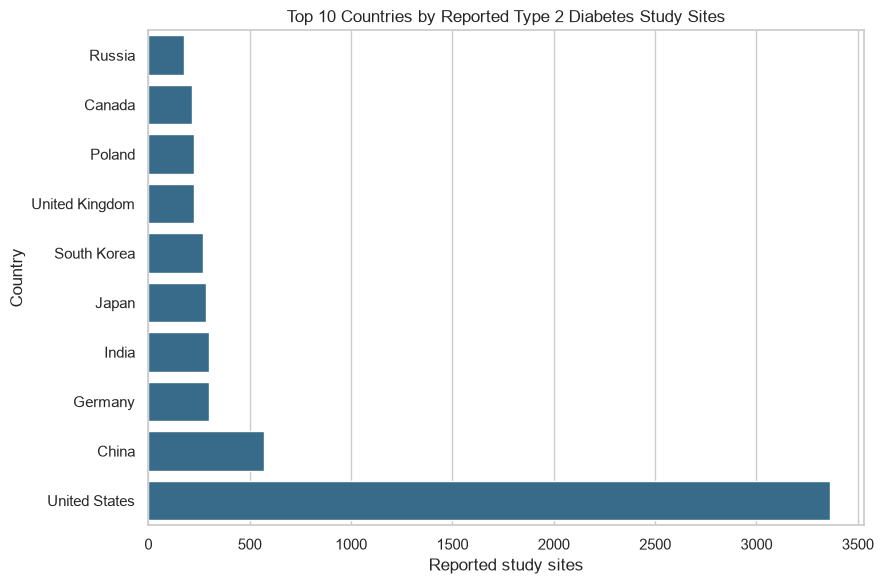

Saved chart to: ..\docs\figures\top_reported_sites_by_country.png


In [32]:
figures_dir = Path("../docs/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

top_countries = country_summary.head(10).sort_values("site_count")

fig, ax = plt.subplots(figsize=(9, 6))

sns.barplot(
    data=top_countries,
    x="site_count",
    y="country",
    color="#2A6F97",
    ax=ax
)

ax.set_title("Top 10 Countries by Reported Type 2 Diabetes Study Sites")
ax.set_xlabel("Reported study sites")
ax.set_ylabel("Country")

fig.tight_layout()

figure_path = figures_dir / "top_reported_sites_by_country.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")

plt.show()

print(f"Saved chart to: {figure_path}")

## Visualisation 2: Typical reported enrollment by study type

Median enrollment is used instead of mean enrollment because a small number of
extremely large studies make the average less representative of a typical study.

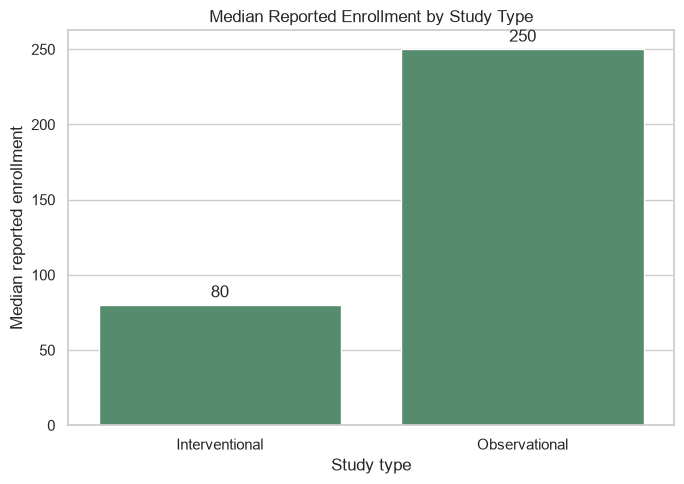

Saved chart to: ..\docs\figures\median_enrollment_by_study_type.png


In [33]:
enrollment_plot = enrollment_by_study_type_sql.copy()

enrollment_plot["study_type"] = (
    enrollment_plot["study_type"]
    .str.replace("_", " ")
    .str.title()
)

fig, ax = plt.subplots(figsize=(7, 5))

sns.barplot(
    data=enrollment_plot,
    x="study_type",
    y="median_enrollment",
    color="#4C956C",
    ax=ax
)

ax.set_title("Median Reported Enrollment by Study Type")
ax.set_xlabel("Study type")
ax.set_ylabel("Median reported enrollment")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

fig.tight_layout()

figure_path = figures_dir / "median_enrollment_by_study_type.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")

plt.show()

print(f"Saved chart to: {figure_path}")